Available columns in the dataset:
Index(['GLORIA_ID', 'Organization_ID', 'Dataset_ID', 'Sample_ID',
       'LIMNADES_ID', 'LIMNADES_UID', 'SeaBASS_ID', 'Data_collection_purpose',
       'Special_event_flag', 'Site_name', 'Country', 'Country_code',
       'Latitude', 'Longitude', 'Date_Time_UTC', 'Water_body_type',
       'Water_type', 'Elevation_asl', 'Wave_height', 'Wind_speed',
       'Cloud_fraction', 'Depth', 'Platform', 'Distance_from_platform',
       'Platform_length', 'Platform_height', 'Distance_to_shore', 'Landcover',
       'Topography', 'Distance_to_river_discharge',
       'Optical_stability_of_water', 'Rain_event_hour',
       'Instrument_manufacturer', 'Instrument_model', 'Last_calibration',
       'Measurement_method', 'Lt_nadir', 'Lt_relative_azimuth', 'Lsky_zenith',
       'Lsky_relative_azimuth', 'Spectral_resolution', 'Number_of_radiometers',
       'Field_of_view_Lt_radiometer', 'Field_of_view_Lu_radiometer',
       'Skyglint_removal', 'Bias_removal_in_NIR', 'Self_

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,468 (9.64 KB)

 Trainable params: 2,468 (9.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1035.2778 - mae: 11.6405 - val_loss: 412.9343 - val_mae: 7.7539
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 517.4256 - mae: 9.1416 - val_loss: 411.9438 - val_mae: 7.7205
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 760.3309 - mae: 10.1302 - val_loss: 410.8056 - val_mae: 7.6844
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 753.7192 - mae: 10.6722 - val_loss: 409.5349 - val_mae: 7.6430
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1135.8781 - mae: 12.2343 - val_loss: 408.0121 - val_mae: 7.5935
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 895.9236 - mae: 11.2376 - val_loss: 406.2845 - val_mae: 7.5361
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 948.8782 - mae: 11.2461 - val_loss: 404.0781 - val_mae: 7.4632
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 785.1044 - mae: 10.7362 - val_loss: 401.2373 - val_mae: 7.3673
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/ste

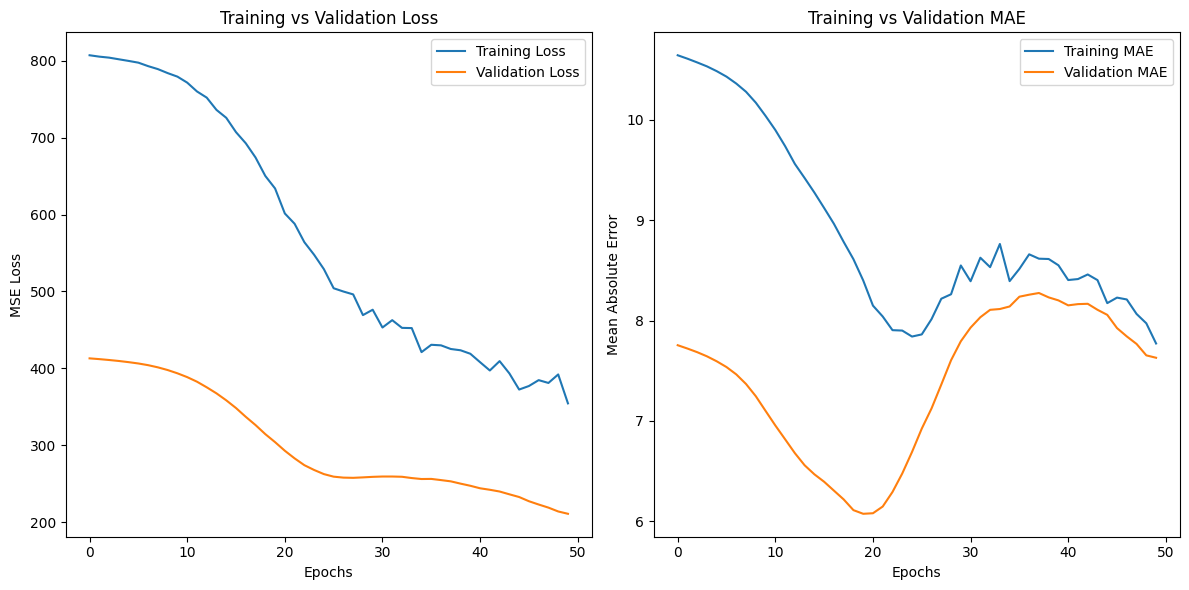

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# ---------------------------
# Step 1: Load and Inspect Data
# ---------------------------

# File path to the GLORIA metadata file
meta_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_meta_and_lab.csv"

# Load the GLORIA metadata file
meta_data = pd.read_csv(meta_data_path)

# Display available columns in the dataset
print("Available columns in the dataset:")
print(meta_data.columns)

# ---------------------------
# Step 2: Select Features and Targets
# ---------------------------

# Define target variables (water quality parameters)
target_columns = ['aCDOM440', 'TSS', 'Chla_plus_phaeo', 'Secchi_depth']

# Define input features (spectral data or other valid columns)
feature_columns = ['Chla', 'TSS', 'aCDOM440']  # Replace with valid feature columns

# Check if all required columns are present in the dataset
missing_targets = [col for col in target_columns if col not in meta_data.columns]
missing_features = [col for col in feature_columns if col not in meta_data.columns]

if missing_targets:
    print(f"Missing target columns: {missing_targets}")
if missing_features:
    print(f"Missing feature columns: {missing_features}")

# Drop rows with missing values in selected columns
valid_columns = list(set(target_columns + feature_columns))
meta_data_cleaned = meta_data.dropna(subset=valid_columns)

# Extract features (X) and targets (y)
X = meta_data_cleaned[feature_columns].values  # Features
y = meta_data_cleaned[target_columns].values   # Targets

print(f"Shape of input features (X): {X.shape}")
print(f"Shape of target variables (y): {y.shape}")

# ---------------------------
# Step 3: Preprocess Data
# ---------------------------

# Normalize the input features to [0, 1]
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# ---------------------------
# Step 4: Build Neural Network Model
# ---------------------------

# Define input layer for features
input_layer = Input(shape=(X_train.shape[1],), name='input_layer')

# Add dense layers for feature extraction
dense1 = Dense(64, activation='relu')(input_layer)
dropout1 = Dropout(0.3)(dense1)
dense2 = Dense(32, activation='relu')(dropout1)

# Output layer for predicting multiple target variables (aCDOM440, TSS, Chla_plus_phaeo, Secchi_depth)
output_layer = Dense(y_train.shape[1], name='output_layer')(dense2)

# Define and compile the model
model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

model.summary()

# ---------------------------
# Step 5: Train the Model
# ---------------------------

history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_split=0.2)

print("\nTraining complete!")

# ---------------------------
# Step 6: Evaluate Model Performance
# ---------------------------

loss, mae = model.evaluate(X_test, y_test)
print(f"\nTest Loss: {loss}, Test MAE: {mae}")

# ---------------------------
# Step 7: Visualize Training History
# ---------------------------

plt.figure(figsize=(12, 6))

# Plot Loss (MSE) over epochs
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training vs Validation Loss')

# Plot MAE over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('Training vs Validation MAE')

plt.tight_layout()
plt.show()


In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import kneighbors_graph
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from spektral.layers import GCNConv
import matplotlib.pyplot as plt

# ---------------------------
# Step 1: Load and Inspect Data
# ---------------------------

# File paths to the GLORIA datasets
meta_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_meta_and_lab.csv"
rrs_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_Rrs.csv"

# Load metadata and spectral reflectance data
meta_data = pd.read_csv(meta_data_path)
rrs_data = pd.read_csv(rrs_data_path)

# Merge datasets on 'GLORIA_ID'
merged_data = pd.merge(meta_data, rrs_data, on='GLORIA_ID', how='inner')

# ---------------------------
# Step 2: Select Features and Targets
# ---------------------------

# Define input features (spectral reflectance values)
feature_columns = [col for col in merged_data.columns if col.startswith('Rrs_')]

# Define target variables (water quality parameters)
target_columns = ['Chla', 'TSS', 'aCDOM440', 'Secchi_depth']

# Drop rows with missing values in selected columns
merged_data_cleaned = merged_data.dropna(subset=feature_columns + target_columns)

# Extract features (X) and targets (y)
X = merged_data_cleaned[feature_columns].values  # Spectral reflectance as input features
y = merged_data_cleaned[target_columns].values   # Water quality parameters as targets

print(f"Shape of input features (X): {X.shape}")
print(f"Shape of target variables (y): {y.shape}")

# ---------------------------
# Step 3: Preprocess Data
# ---------------------------

# Normalize the input features to [0, 1]
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# ---------------------------
# Step 4: Create Adjacency Matrix for GNN Branch
# ---------------------------

# Create adjacency matrix using k-nearest neighbors (k=5)
A = kneighbors_graph(X_train, n_neighbors=5, mode='connectivity', include_self=True)
A_dense = A.toarray().astype('float32')  # Convert to dense numpy array

print("\nAdjacency matrix shape:", A_dense.shape)

# ---------------------------
# Step 5: Build Hybrid CNN-GNN Model
# ---------------------------

# Define CNN input and branch for spectral data
input_cnn = Input(shape=(X_train.shape[1], 1), name='cnn_input')
cnn_branch = Conv1D(filters=16, kernel_size=3, activation='relu')(input_cnn)
cnn_branch = Flatten()(cnn_branch)

# Define GNN input and branch for graph-based relationships
input_gnn = Input(shape=(X_train.shape[1],), name='gnn_input')
adj_input = tf.constant(A_dense)  # Static adjacency matrix for GNN branch

gnn_branch = GCNConv(16, activation='relu')([input_gnn, adj_input])
gnn_branch = Flatten()(gnn_branch)

# Merge CNN and GNN branches
merged = Concatenate()([cnn_branch, gnn_branch])
dense1 = Dense(64, activation='relu')(merged)
dropout1 = Dropout(0.3)(dense1)
output_layer = Dense(y_train.shape[1], name='output_layer')(dropout1)  # Multi-output regression

# Define and compile the model
model = Model(inputs=[input_cnn, input_gnn], outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

model.summary()

# ---------------------------
# Step 6: Train the Model
# ---------------------------

# Reshape X_train for CNN input (add channel dimension for Conv1D)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

history = model.fit([X_train_cnn, X_train],
                    y_train,
                    epochs=50,
                    batch_size=16,
                    validation_split=0.2)

print("\nTraining complete!")

# ---------------------------
# Step 7: Evaluate Model Performance
# ---------------------------

loss, mae = model.evaluate([X_test_cnn, X_test], y_test)
print(f"\nTest Loss: {loss}, Test MAE: {mae}")

# ---------------------------
# Step 8: Visualize Training History
# ---------------------------

plt.figure(figsize=(12, 6))

# Plot Loss (MSE) over epochs
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training vs Validation Loss')

# Plot MAE over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('Training vs Validation MAE')

plt.tight_layout()
plt.show()


Shape of input features (X): (229, 551)
Shape of target variables (y): (229, 4)
Training set size: 183
Testing set size: 46

Adjacency matrix shape: (183, 183)


ValueError: Exception encountered when calling GCNConv.call().

[1mCould not automatically infer the output shape / dtype of 'gcn_conv_1' (of type GCNConv). Either the `GCNConv.call()` method is incorrect, or you need to implement the `GCNConv.compute_output_spec() / compute_output_shape()` method. Error encountered:

Tried to convert 'y' to a tensor and failed. Error: None values not supported.[0m

Arguments received by GCNConv.call():
  • args=(['<KerasTensor shape=(None, 551), dtype=float32, sparse=False, name=gnn_input>', 'tf.Tensor(shape=(183, 183), dtype=float32)'],)
  • kwargs={'mask': ['None', 'None']}

In [11]:
from sklearn.neighbors import kneighbors_graph

# Recreate adjacency matrix after splitting data
A = kneighbors_graph(X_train, n_neighbors=5, mode='connectivity', include_self=True)
A_dense = A.toarray().astype('float32')

# Define GNN input and branch for graph-based relationships
input_gnn = Input(shape=(X_train.shape[1],), name='gnn_input')
adj_input = tf.constant(A_dense, dtype=tf.float32)

# Apply GCNConv layer
gnn_branch = GCNConv(16, activation='relu')([input_gnn, adj_input])
gnn_branch = Flatten()(gnn_branch)

print("GNN branch created successfully!")


ValueError: Exception encountered when calling GCNConv.call().

[1mCould not automatically infer the output shape / dtype of 'gcn_conv_2' (of type GCNConv). Either the `GCNConv.call()` method is incorrect, or you need to implement the `GCNConv.compute_output_spec() / compute_output_shape()` method. Error encountered:

Tried to convert 'y' to a tensor and failed. Error: None values not supported.[0m

Arguments received by GCNConv.call():
  • args=(['<KerasTensor shape=(None, 551), dtype=float32, sparse=False, name=gnn_input>', 'tf.Tensor(shape=(183, 183), dtype=float32)'],)
  • kwargs={'mask': ['None', 'None']}

In [5]:
# Load Metadata File
meta_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_meta_and_lab.csv"
meta_data = pd.read_csv(meta_data_path)

# Load Spectral Reflectance Data (if in CSV format)
rrs_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_Rrs.csv"
rrs_data = pd.read_csv(rrs_data_path)

# Merge Metadata with Spectral Data
meta_data = pd.merge(meta_data, rrs_data, on='Sample_ID', how='inner')

# Select Features and Targets
feature_columns = ['Rrs_443', 'Rrs_560', 'Rrs_665']  # Spectral reflectance values
target_columns = ['aCDOM440', 'TSS', 'Chla_plus_phaeo', 'Secchi_depth']

meta_data_cleaned = meta_data.dropna(subset=feature_columns + target_columns)
X = meta_data_cleaned[feature_columns].values  # Features: Spectral Reflectance
y = meta_data_cleaned[target_columns].values   # Targets: Water Quality Parameters

# Preprocess Data
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

# Build Neural Network Model
input_layer = Input(shape=(X_train.shape[1],), name='input_layer')
dense1 = Dense(64, activation='relu')(input_layer)
dropout1 = Dropout(0.3)(dense1)
dense2 = Dense(32, activation='relu')(dropout1)
output_layer = Dense(y_train.shape[1], name='output_layer')(dense2)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Train Model
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_split=0.2)

# Evaluate Model Performance
loss, mae = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss}, Test MAE: {mae}")


KeyError: 'Sample_ID'

In [6]:
import pandas as pd

# Load both datasets
meta_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_meta_and_lab.csv"
rrs_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_Rrs.csv"

meta_data = pd.read_csv(meta_data_path)
rrs_data = pd.read_csv(rrs_data_path)

# Print column names
print("Columns in meta_data:")
print(meta_data.columns)

print("\nColumns in rrs_data:")
print(rrs_data.columns)


Columns in meta_data:
Index(['GLORIA_ID', 'Organization_ID', 'Dataset_ID', 'Sample_ID',
       'LIMNADES_ID', 'LIMNADES_UID', 'SeaBASS_ID', 'Data_collection_purpose',
       'Special_event_flag', 'Site_name', 'Country', 'Country_code',
       'Latitude', 'Longitude', 'Date_Time_UTC', 'Water_body_type',
       'Water_type', 'Elevation_asl', 'Wave_height', 'Wind_speed',
       'Cloud_fraction', 'Depth', 'Platform', 'Distance_from_platform',
       'Platform_length', 'Platform_height', 'Distance_to_shore', 'Landcover',
       'Topography', 'Distance_to_river_discharge',
       'Optical_stability_of_water', 'Rain_event_hour',
       'Instrument_manufacturer', 'Instrument_model', 'Last_calibration',
       'Measurement_method', 'Lt_nadir', 'Lt_relative_azimuth', 'Lsky_zenith',
       'Lsky_relative_azimuth', 'Spectral_resolution', 'Number_of_radiometers',
       'Field_of_view_Lt_radiometer', 'Field_of_view_Lu_radiometer',
       'Skyglint_removal', 'Bias_removal_in_NIR', 'Self_shading_corr

Columns in meta_data:
Index(['GLORIA_ID', 'Organization_ID', 'Dataset_ID', 'Sample_ID',
       'LIMNADES_ID', 'LIMNADES_UID', 'SeaBASS_ID', 'Data_collection_purpose',
       'Special_event_flag', 'Site_name', 'Country', 'Country_code',
       'Latitude', 'Longitude', 'Date_Time_UTC', 'Water_body_type',
       'Water_type', 'Elevation_asl', 'Wave_height', 'Wind_speed',
       'Cloud_fraction', 'Depth', 'Platform', 'Distance_from_platform',
       'Platform_length', 'Platform_height', 'Distance_to_shore', 'Landcover',
       'Topography', 'Distance_to_river_discharge',
       'Optical_stability_of_water', 'Rain_event_hour',
       'Instrument_manufacturer', 'Instrument_model', 'Last_calibration',
       'Measurement_method', 'Lt_nadir', 'Lt_relative_azimuth', 'Lsky_zenith',
       'Lsky_relative_azimuth', 'Spectral_resolution', 'Number_of_radiometers',
       'Field_of_view_Lt_radiometer', 'Field_of_view_Lu_radiometer',
       'Skyglint_removal', 'Bias_removal_in_NIR', 'Self_shading_corr

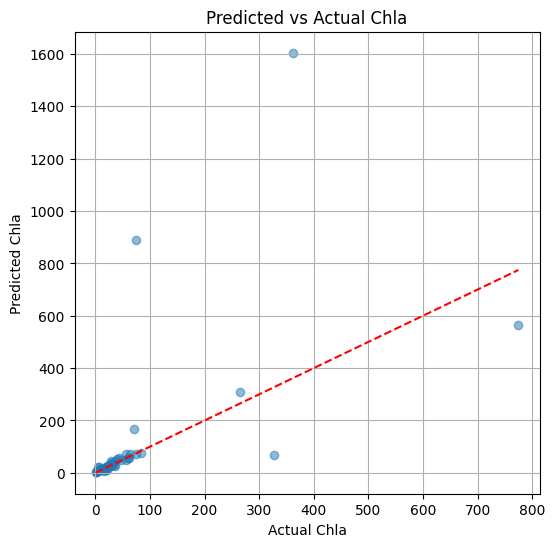

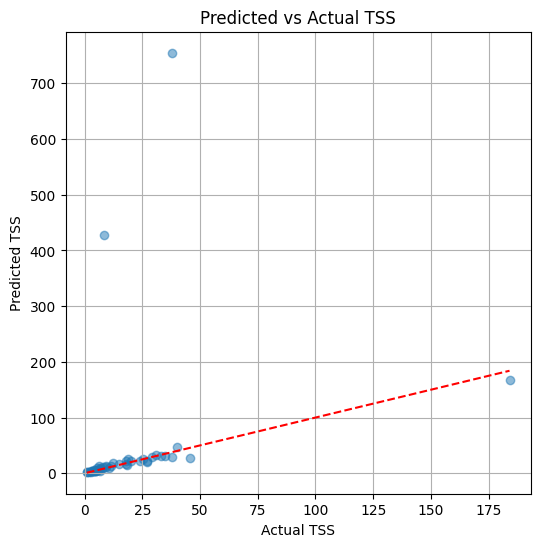

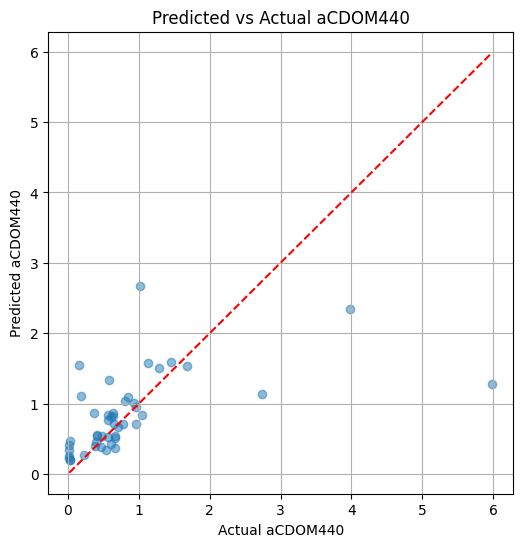

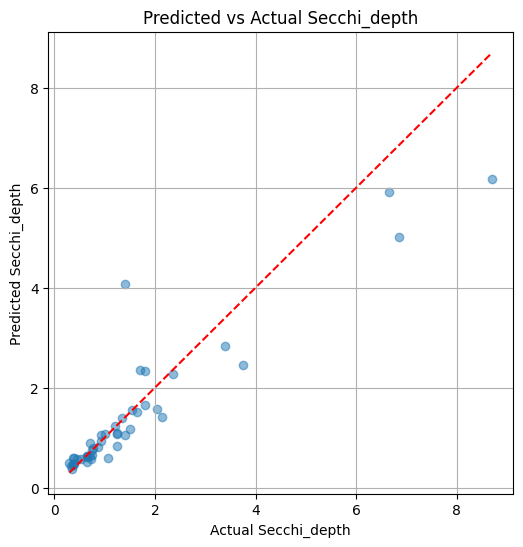

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# ---------------------------
# Step 1: Load and Inspect Data
# ---------------------------

# File paths to the GLORIA datasets
meta_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_meta_and_lab.csv"
rrs_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_Rrs.csv"

# Load metadata and spectral reflectance data
meta_data = pd.read_csv(meta_data_path)
rrs_data = pd.read_csv(rrs_data_path)

# Display column names in both datasets
print("Columns in meta_data:")
print(meta_data.columns)

print("\nColumns in rrs_data:")
print(rrs_data.columns)

# ---------------------------
# Step 2: Merge Datasets on GLORIA_ID
# ---------------------------

# Merge both datasets using the common key 'GLORIA_ID'
merged_data = pd.merge(meta_data, rrs_data, on='GLORIA_ID', how='inner')

# Display merged dataset sample
print("\nMerged dataset sample:")
print(merged_data.head())

# ---------------------------
# Step 3: Select Features and Targets
# ---------------------------

# Define input features (spectral reflectance values)
feature_columns = [col for col in merged_data.columns if col.startswith('Rrs_')]

# Define target variables (water quality parameters)
target_columns = ['Chla', 'TSS', 'aCDOM440', 'Secchi_depth']

# Drop rows with missing values in selected columns
merged_data_cleaned = merged_data.dropna(subset=feature_columns + target_columns)

# Extract features (X) and targets (y)
X = merged_data_cleaned[feature_columns].values  # Spectral reflectance as input features
y = merged_data_cleaned[target_columns].values   # Water quality parameters as targets

print(f"\nShape of input features (X): {X.shape}")
print(f"Shape of target variables (y): {y.shape}")

# ---------------------------
# Step 4: Preprocess Data
# ---------------------------

# Normalize the input features to [0, 1]
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

print("\nNormalized features sample:")
print(X_normalized[:5])

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# ---------------------------
# Step 5: Train Machine Learning Model
# ---------------------------

# Train a Random Forest model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Evaluate model performance on the test set
score = model.score(X_test, y_test)
print(f"\nModel R^2 Score: {score}")

# ---------------------------
# Step 6: Visualize Predictions
# ---------------------------

y_pred = model.predict(X_test)

for i, target in enumerate(target_columns):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test[:, i], y_pred[:, i], alpha=0.5)
    plt.plot([y_test[:, i].min(), y_test[:, i].max()],
             [y_test[:, i].min(), y_test[:, i].max()], 'r--')
    plt.xlabel(f"Actual {target}")
    plt.ylabel(f"Predicted {target}")
    plt.title(f"Predicted vs Actual {target}")
    plt.grid()
    plt.show()



In [15]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import kneighbors_graph
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from spektral.layers import GCNConv
import matplotlib.pyplot as plt

# ---------------------------
# Step 1: Load and Inspect Data
# ---------------------------
meta_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_meta_and_lab.csv"
rrs_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_Rrs.csv"

# Load metadata and spectral reflectance data
meta_data = pd.read_csv(meta_data_path)
rrs_data = pd.read_csv(rrs_data_path)

# Merge both datasets using the common key 'GLORIA_ID'
merged_data = pd.merge(meta_data, rrs_data, on='GLORIA_ID', how='inner')

# ---------------------------
# Step 2: Select Features and Targets
# ---------------------------
# Define input features (all columns that start with 'Rrs_')
feature_columns = [col for col in merged_data.columns if col.startswith('Rrs_')]

# Define target variables (replace 'Chla' with 'Chla_plus_phaeo')
target_columns = ['Chla_plus_phaeo', 'TSS', 'aCDOM440', 'Secchi_depth']

# Drop rows with missing values in the selected columns
merged_data_cleaned = merged_data.dropna(subset=feature_columns + target_columns)

# Extract features (X) and targets (y)
X = merged_data_cleaned[feature_columns].values  # Spectral reflectance features
y = merged_data_cleaned[target_columns].values   # Water quality parameters

print(f"Shape of input features (X): {X.shape}")
print(f"Shape of target variables (y): {y.shape}")

# ---------------------------
# Step 3: Preprocess Data
# ---------------------------
# Normalize the input features to [0, 1]
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# For full-batch graph training in the GNN branch, use the training set only
num_train = X_train.shape[0]

# ---------------------------
# Step 4: Create Adjacency Matrix for the GNN Branch
# ---------------------------
# Create a k-nearest neighbors graph (with k=5) using the training data
A = kneighbors_graph(X_train, n_neighbors=5, mode='connectivity', include_self=True)
A = A.tocoo()  # Convert to COO format for easier manipulation

# Build SparseTensor indices and create a TensorFlow SparseTensor with fixed shape
indices = np.vstack((A.row, A.col)).transpose()
A_tf = tf.sparse.SparseTensor(indices, A.data.astype('float32'), A.shape)
A_tf = tf.sparse.reorder(A_tf)  # Reorder to ensure proper internal representation

print("Adjacency matrix shape:", A.shape)

# ---------------------------
# Step 5: Build the Hybrid CNN-GNN Model
# ---------------------------
# CNN Branch: Process spectral data (each node individually)
input_cnn = Input(shape=(X_train.shape[1], 1), name='cnn_input')
cnn_branch = Conv1D(filters=16, kernel_size=3, activation='relu')(input_cnn)
cnn_branch = Flatten()(cnn_branch)

# GNN Branch: Process node features for graph-based relationships
# We use a Keras Input for node features only; the adjacency matrix is a fixed constant.
input_gnn = Input(shape=(X_train.shape[1],), name='gnn_input')
gnn_branch = GCNConv(16, activation='relu')([input_gnn, A_tf])
gnn_branch = Flatten()(gnn_branch)

# Merge the outputs of the CNN and GNN branches
merged = Concatenate()([cnn_branch, gnn_branch])
dense = Dense(64, activation='relu')(merged)
dense = Dropout(0.3)(dense)
output_layer = Dense(y_train.shape[1], name='output')(dense)

# Define and compile the model
model = Model(inputs=[input_cnn, input_gnn], outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

# ---------------------------
# Step 6: Train the Model
# ---------------------------
# Reshape X_train for the CNN branch (add a channel dimension required by Conv1D)
X_train_cnn = X_train.reshape(num_train, X_train.shape[1], 1)

# Since the graph convolution is applied in full-batch mode, set the batch size to num_train.
history = model.fit([X_train_cnn, X_train],
                    y_train,
                    epochs=50,
                    batch_size=num_train,
                    validation_split=0.2,
                    verbose=1)

print("\nTraining complete!")

# ---------------------------
# Step 7: Evaluate Model Performance
# ---------------------------
loss, mae = model.evaluate([X_train_cnn, X_train], y_train, verbose=0)
print(f"\nTraining Loss: {loss}, Training MAE: {mae}")

# ---------------------------
# Step 8: Visualize Training History
# ---------------------------
plt.figure(figsize=(12, 6))

# Plot training vs validation loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training vs Validation Loss')

# Plot training vs validation MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('Training vs Validation MAE')

plt.tight_layout()
plt.show()


Shape of input features (X): (95, 551)
Shape of target variables (y): (95, 4)
Training set size: 76
Testing set size: 19
Adjacency matrix shape: (76, 76)


ValueError: Exception encountered when calling GCNConv.call().

[1mCould not automatically infer the output shape / dtype of 'gcn_conv_6' (of type GCNConv). Either the `GCNConv.call()` method is incorrect, or you need to implement the `GCNConv.compute_output_spec() / compute_output_shape()` method. Error encountered:

Tried to convert 'y' to a tensor and failed. Error: None values not supported.[0m

Arguments received by GCNConv.call():
  • args=(['<KerasTensor shape=(None, 551), dtype=float32, sparse=False, name=gnn_input>', 'tf.Tensor(shape=(76, 76), dtype=float32)'],)
  • kwargs={'mask': ['None', 'None']}

Merged dataset sample:
  GLORIA_ID Organization_ID        Dataset_ID Sample_ID LIMNADES_ID  \
0     GID_1           UT-TO  AlikasK_EE_UT-TO        53         NaN   
1     GID_2           UT-TO  AlikasK_EE_UT-TO        54         NaN   
2     GID_3           UT-TO  AlikasK_EE_UT-TO        55         NaN   
3     GID_4           UT-TO  AlikasK_EE_UT-TO        56         NaN   
4     GID_5           UT-TO  AlikasK_EE_UT-TO        57         NaN   

  LIMNADES_UID SeaBASS_ID  Data_collection_purpose  Special_event_flag  \
0          NaN        NaN                      3.0                 NaN   
1          NaN        NaN                      3.0                 NaN   
2          NaN        NaN                      3.0                 NaN   
3          NaN        NaN                      3.0                 NaN   
4          NaN        NaN                      3.0                 NaN   

     Site_name  ...   Rrs_891   Rrs_892   Rrs_893   Rrs_894   Rrs_895  \
0  Lake Peipsi  ...  0.000274  0

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_input (InputLayer)          │ (None, 551, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 549, 16)        │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 8784)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       562,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 562,564 (2.15 MB)

 Trainable params: 562,564 (2.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 204.4819 - mae: 8.1567 - val_loss: 128.0089 - val_mae: 7.2278
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 142.7651 - mae: 6.9038 - val_loss: 95.9212 - val_mae: 6.3723
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 147.4970 - mae: 7.1296 - val_loss: 65.4125 - val_mae: 5.2260
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 157.3978 - mae: 6.8536 - val_loss: 42.6394 - val_mae: 4.2075
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 98.0659 - mae: 5.4118 - val_loss: 32.2390 - val_mae: 4.0433
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 97.7303 - mae: 5.9733 - val_loss: 28.4569 - val_mae: 4.0243
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 73.8365 - mae: 5.4741 - val_loss: 26.7695 - val_mae: 3.8306
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 105.3720 - mae: 6.0447 - val_loss: 25.8934 - val_mae: 3.4895
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 8

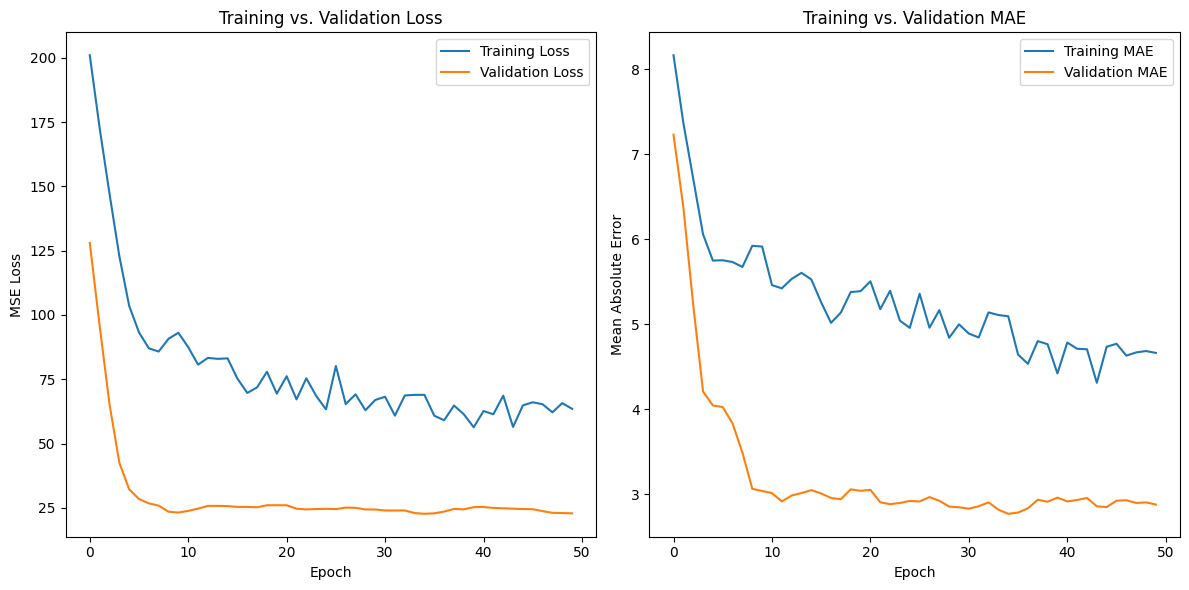

In [16]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv1D, Flatten, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# ---------------------------
# Step 1: Load and Inspect Data
# ---------------------------
# File paths to the GLORIA datasets; update these paths if needed
meta_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_meta_and_lab.csv"
rrs_data_path  = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_Rrs.csv"

# Load metadata and spectral reflectance data
meta_data = pd.read_csv(meta_data_path)
rrs_data  = pd.read_csv(rrs_data_path)

# Merge datasets on 'GLORIA_ID'
merged_data = pd.merge(meta_data, rrs_data, on='GLORIA_ID', how='inner')

print("Merged dataset sample:")
print(merged_data.head())

# ---------------------------
# Step 2: Select Features and Targets
# ---------------------------
# Define input features as all columns that start with "Rrs_"
feature_columns = [col for col in merged_data.columns if col.startswith('Rrs_')]

# Define target variables (replace "Chla" with "Chla_plus_phaeo")
target_columns = ['Chla_plus_phaeo', 'TSS', 'aCDOM440', 'Secchi_depth']

# Drop rows with missing values in selected columns
merged_data_cleaned = merged_data.dropna(subset=feature_columns + target_columns)

# Extract features (X) and targets (y)
X = merged_data_cleaned[feature_columns].values    # Spectral reflectance features
y = merged_data_cleaned[target_columns].values       # Water quality parameters

print(f"\nShape of input features (X): {X.shape}")
print(f"Shape of target variables (y): {y.shape}")

# ---------------------------
# Step 3: Preprocess the Data
# ---------------------------
# Normalize spectral features to the [0, 1] range
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# ---------------------------
# Step 4: Build the Pure CNN Model
# ---------------------------
# The CNN will process each sample’s spectral data, which needs to be reshaped 
# to have a channel dimension. For example, if there are N features, the input shape
# should be (N, 1).
input_cnn = Input(shape=(X_train.shape[1], 1), name='cnn_input')

# Add a 1D convolution layer to extract local spectral features
x = Conv1D(filters=16, kernel_size=3, activation='relu')(input_cnn)
x = Flatten()(x)

# Add fully-connected layers with dropout for regularization
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

# Output layer: the number of neurons equals the number of target parameters
output = Dense(y_train.shape[1], name='output')(x)

# Define and compile the CNN model
model = Model(inputs=input_cnn, outputs=output)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

# ---------------------------
# Step 5: Prepare Data and Train the Model
# ---------------------------
# Reshape X_train and X_test to add the channel dimension required by Conv1D
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0],  X_test.shape[1], 1)

# Train the model
history = model.fit(
    X_train_cnn, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

print("\nTraining complete!")

# ---------------------------
# Step 6: Evaluate Model Performance
# ---------------------------
loss, mae = model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"\nTest Loss (MSE): {loss}, Test MAE: {mae}")

# ---------------------------
# Step 7: Visualize Training History and Results
# ---------------------------
plt.figure(figsize=(12, 6))

# Plot training vs. validation loss (MSE) over epochs
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training vs. Validation Loss')

# Plot training vs. validation MAE over epochs
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.title('Training vs. Validation MAE')

plt.tight_layout()
plt.show()


In [17]:
# Import necessary libraries for testing
import os
import xarray as xr
import numpy as np

# ----------------------------------------------------------------
# Configuration: Adjust the following directory path as needed
# ----------------------------------------------------------------
# Directory containing the Sentinel-3 OLCI .nc files
olci_nc_directory = "C:/Users/BraedynM/Documents/Science Fair 2025/OLCI_dataset"  # Update this to your actual directory

# ----------------------------------------------------------------
# Retrieve a list of NetCDF files in the directory
# ----------------------------------------------------------------
try:
    nc_files = [f for f in os.listdir(olci_nc_directory) if f.endswith('.nc')]
except FileNotFoundError:
    raise FileNotFoundError(f"Directory '{olci_nc_directory}' not found. Please update the path.")

# ----------------------------------------------------------------
# Determine the expected number of features (spectral bands)
# obtained from the trained model's CNN input shape.
# For a model trained with inputs of shape (num_features, 1):
# ----------------------------------------------------------------
expected_n_features = model.input_shape[1]  # e.g., if input shape is (None, 64, 1) then expected_n_features == 64

print("\nTesting OLCI .nc files with the trained CNN model:")
for nc_file in nc_files:
    file_path = os.path.join(olci_nc_directory, nc_file)
    try:
        # Open the NetCDF file using xarray
        ds = xr.open_dataset(file_path)
    except Exception as e:
        print(f"Error opening '{nc_file}': {e}")
        continue

    # Check that the dataset contains a variable named "reflectance"
    if "reflectance" not in ds.variables:
        print(f"File '{nc_file}' does not contain a 'reflectance' variable. Skipping.")
        continue

    # Extract the reflectance values
    ref_vals = ds["reflectance"].values

    # Average over spatial dimensions if the reflectance array is multidimensional.
    # For a 3D array (e.g., height x width x bands): average over height and width.
    # For a 2D array (e.g., if data is already spatially collapsed): average over the first axis.
    if ref_vals.ndim == 3:
        sample = np.mean(ref_vals, axis=(0, 1))
    elif ref_vals.ndim == 2:
        sample = np.mean(ref_vals, axis=0)
    elif ref_vals.ndim == 1:
        sample = ref_vals
    else:
        print(f"File '{nc_file}' has unsupported number of dimensions: {ref_vals.ndim}. Skipping.")
        continue

    # Verify that the resulting sample has the expected number of spectral bands/features
    if sample.shape[0] != expected_n_features:
        print(f"File '{nc_file}' has {sample.shape[0]} features; expected {expected_n_features}. Skipping.")
        continue

    # Scale the sample using the same scaler fitted during training.
    # The scaler expects a 2D input, so reshape to (1, -1)
    sample_scaled = scaler.transform(sample.reshape(1, -1))
    
    # Reshape the sample for the CNN model (add the channel dimension: (1, expected_n_features, 1))
    sample_ready = sample_scaled.reshape(1, expected_n_features, 1)

    # Predict water quality parameters using the trained CNN model
    prediction = model.predict(sample_ready)
    print(f"File: {nc_file} --> Predicted water quality parameters: {prediction}")



Testing OLCI .nc files with the trained CNN model:
File 'geo_coordinates.nc' does not contain a 'reflectance' variable. Skipping.
File 'instrument_data.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa01_radiance.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa01_radiance_unc.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa02_radiance.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa02_radiance_unc.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa03_radiance.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa03_radiance_unc.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa04_radiance.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa04_radiance_unc.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa05_radiance.nc' does not contain a 'reflectance' variable. Skipping.
File 'Oa05_radiance_unc.nc' does not contain a 'reflectance' variable. Skipping.


c:\Users\BraedynM\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\namedarray\core.py:264: UserWarning: Duplicate dimension names present: dimensions {'bands'} appear more than once in dims=('bands', 'bands'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
c:\Users\BraedynM\AppData\Local\Programs\Python\Python312\Lib\site-packages\xarray\namedarray\core.py:264: UserWarning: Duplicate dimension names present: dimensions {'bands'} appear more than once in dims=('bands', 'bands'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately t

In [20]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import pickle

# ---------------------------
# Load and preprocess the GLORIA dataset
# ---------------------------
# Paths to your GLORIA dataset files (update file paths)
meta_data_path = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_meta_and_lab.csv"
rrs_data_path  = "C:/Users/BraedynM/Documents/Science Fair 2025/GLORIA_dataset/GLORIA_Rrs.csv"

# Load CSV files
meta_data = pd.read_csv(meta_data_path)
rrs_data  = pd.read_csv(rrs_data_path)

# Merge datasets using the GLORIA_ID key
merged_data = pd.merge(meta_data, rrs_data, on='GLORIA_ID', how='inner')

# Define features and targets.
# Assume spectral features are columns beginning with "Rrs_" and targets include "Chla_plus_phaeo", "TSS", "aCDOM440", "Secchi_depth"
feature_columns = [col for col in merged_data.columns if col.startswith('Rrs_')]
target_columns = ['Chla_plus_phaeo', 'TSS', 'aCDOM440', 'Secchi_depth']

# Drop rows with missing values
merged_data_cleaned = merged_data.dropna(subset=feature_columns + target_columns)

# Extract feature and target arrays
X = merged_data_cleaned[feature_columns].values
y = merged_data_cleaned[target_columns].values

print("Shape of features (X):", X.shape)
print("Shape of targets (y):", y.shape)

# ---------------------------
# Data Scaling and Splitting
# ---------------------------
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])

# ---------------------------
# Build a simple fully-connected (CNN-free) model.
# (Note: In your ipynb file the model appears very simple, with input dimension equal to the number of features.)
# ---------------------------
input_layer = Input(shape=(X_train.shape[1],), name='input_layer')
x = Dense(64, activation='relu')(input_layer)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
output_layer = Dense(y_train.shape[1], name='output_layer')(x)

model = Model(inputs=input_layer, outputs=output_layer)
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

# ---------------------------
# Train the Model
# ---------------------------
history = model.fit(X_train, y_train, epochs=2000, batch_size=16, validation_split=0.2, verbose=1)

loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("\nTest Loss (MSE):", loss, "Test MAE:", mae)

# ---------------------------
# Save the Trained Model and Scaler to Files
# ---------------------------
# Save the model in HDF5 format
model.save("my_model.h5")
print("Model saved as 'my_model.h5'.")

# Save the fitted scaler using pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
print("Scaler saved as 'scaler.pkl'.")


Shape of features (X): (95, 551)
Shape of targets (y): (95, 4)
Training set size: 76
Testing set size: 19


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 551)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │        35,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,540 (146.64 KB)

 Trainable params: 37,540 (146.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 244.1680 - mae: 9.1329 - val_loss: 145.0280 - val_mae: 7.8757
Epoch 2/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 183.3913 - mae: 8.0102 - val_loss: 128.5756 - val_mae: 7.5173
Epoch 3/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 179.5860 - mae: 7.9623 - val_loss: 110.6496 - val_mae: 7.0629
Epoch 4/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 172.9853 - mae: 7.7973 - val_loss: 91.5789 - val_mae: 6.5096
Epoch 5/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 135.5234 - mae: 6.8948 - val_loss: 73.4008 - val_mae: 5.8764
Epoch 6/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 98.7639 - mae: 5.8744 - val_loss: 57.5398 - val_mae: 5.2876
Epoch 7/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 120.8230 - mae: 6.4734 - val_loss: 44.8367 - val_mae: 4.7994
Epoch 8/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 116.8530 - mae: 6.4689 - val_loss: 37.0335 - val_mae: 4.4726
Epoch 9/2000
4/4 ━━━━━━━━━━━━━━━━━━━━ 

 13.791135787963867 Test MAE: 2.0647549629211426
Model saved as 'my_model.h5'.
Scaler saved as 'scaler.pkl'.
